# Cluster

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from esda.moran import Moran
from libpysal.weights import KNN
import seaborn as sns
from pysal.lib import weights
import pysal as ps
from sklearn import cluster
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics.cluster import silhouette_score


In [100]:
cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/df_catchments_spatial.gpkg")
cat.head(1)

,id,Nombre,ID_CUENCA,cuenca,area,elev_mean,elev_median,rel_mean,rel_median,rainfallAnnual_mean,Densidad,hypso_inte,slope_mean,kmeans,RainfallDaysmean,RainfallDaysmedian,landcovermedian,geomedian,lands_rec,geometry
0,1,Quebrada Guaco,606.0,Cauca,18443928,1615.334363,1607.0,510.665139,505.0,2264.807895,18.23095,0.493,29.278027,C,1112.245024,1066.0,grass,sediment,4.0,"POLYGON ((454732.740 622820.251, 454684.825 62..."


In [101]:
var=['hypso_inte','elev_mean','slope_mean','rel_mean']

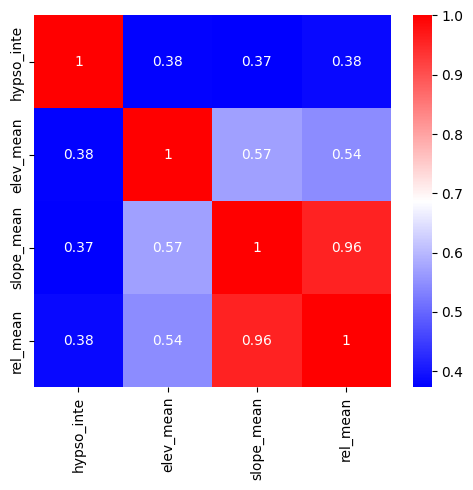

In [102]:
plt.figure(figsize=(5,5))
cor = cat[var].corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.bwr)
plt.tight_layout()
plt.savefig('G:\My Drive\INVESTIGACION\POSDOC\Figuras\corre_catchments.png', dpi=500)

KeyError: '[526] not in index'

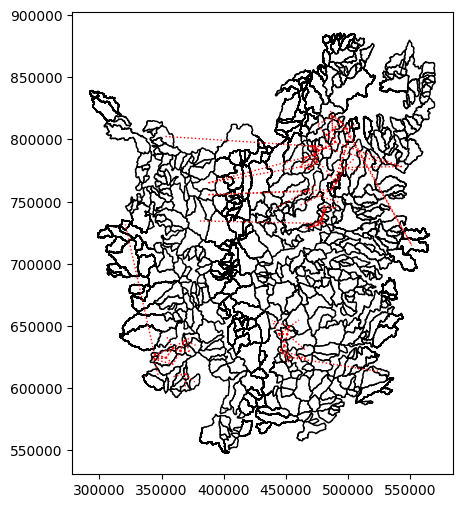

In [103]:
f, axs = plt.subplots(figsize=(6,6))
ax = cat.plot(edgecolor="k", facecolor="w", ax=axs)
w_k4.plot(cat,ax=axs,edge_kws=dict(color="r", linestyle=":", linewidth=1),node_kws=dict(marker=""),)
axs.set_axis_off()
f.savefig('G:\My Drive\INVESTIGACION\POSDOC\Figuras\w_k4.png', dpi=500)

In [ ]:
f, axs = plt.subplots(figsize=(6,6))
cat.plot(edgecolor="k", facecolor="w", ax=axs)
w_d30.plot(cat,ax=axs,edge_kws=dict(color="r", linestyle=":", linewidth=1),node_kws=dict(marker=""),)
axs.set_axis_off()
f.savefig('G:\My Drive\INVESTIGACION\POSDOC\Figuras\w_d30.png', dpi=500)

In [ ]:
f, axs = plt.subplots(figsize=(6,6))
cat.plot(edgecolor="k", facecolor="w", ax=axs)
w_kernel4.plot(cat,ax=axs,edge_kws=dict(color="r", linestyle=":", linewidth=1),node_kws=dict(marker=""),)
axs.set_axis_off()
f.savefig('G:\My Drive\INVESTIGACION\POSDOC\Figuras\w_kernel4.png', dpi=500)

NameError: name 'w_d' is not defined

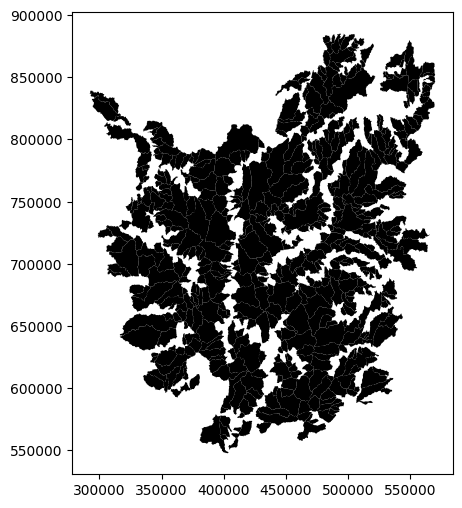

In [104]:
ax = cat.plot(color='k', figsize=(5,6))
cat.loc[w_d.islands, :].plot(color='red', ax=ax);

In [105]:
mi_results = [Moran(cat[variable], w_k4) for variable in var]
table = pd.DataFrame([(variable, res.I, res.p_sim) for variable,res in zip(var, mi_results)], columns=['Variable', "Moran's I", 'P-value']).set_index('Variable')
table

ValueError: dimension mismatch

In [106]:
from sklearn.preprocessing import StandardScaler
cat_std= StandardScaler().fit_transform(cat[var])

In [107]:
from scipy.cluster.hierarchy import dendrogram,linkage
Z=linkage(cat_std,method='ward',metric='euclidean')

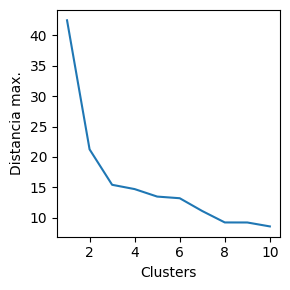

In [108]:
last=Z[-10:,2]
last_rev=last[::-1] #e voltean
idx=np.arange(1,len(last)+1)
plt.figure(figsize=(3,3))
plt.plot(idx,last_rev)
plt.xlabel('Clusters')
plt.ylabel('Distancia max.')
plt.tight_layout()
plt.savefig('G:\My Drive\INVESTIGACION\POSDOC\Figuras\cluster_elbow.png', dpi=500);

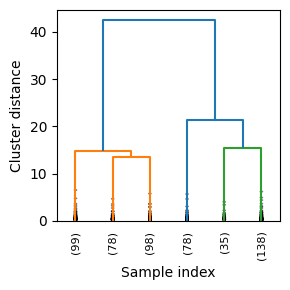

In [109]:
plt.figure(figsize=(3,3))
plt.xlabel('Sample index')
plt.ylabel('Cluster distance');
dendrogram(Z,leaf_rotation=90.,leaf_font_size=8,color_threshold=0.2*83,truncate_mode='lastp',p=6,show_leaf_counts=True,show_contracted=True)
plt.tight_layout()
plt.savefig('G:\My Drive\INVESTIGACION\POSDOC\Figuras\cluster_dendro.png', dpi=500)

In [110]:
k4cls = cluster.KMeans(n_clusters=4).fit(cat_std)

C:\Users\edier\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [111]:
cat['kmeans4'] = k4cls.labels_

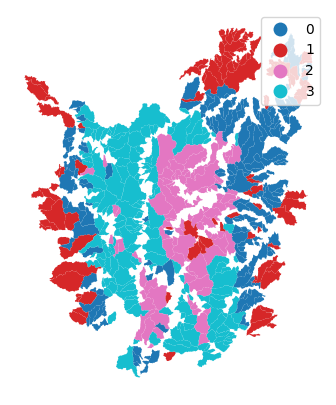

In [112]:
f, ax = plt.subplots(figsize=(5, 5))
cat.plot(column='kmeans4', categorical=True, legend=True, linewidth=0, ax=ax)
ax.set_axis_off()
plt.savefig('G:\My Drive\INVESTIGACION\POSDOC\Figuras\cluster_kmeans4.png', dpi=500)

In [113]:
print(silhouette_score(cat_std,k4cls.labels_))

0.3132612979327485


<Axes: title={'center': 'hypso_inte'}, xlabel='kmeans4'>

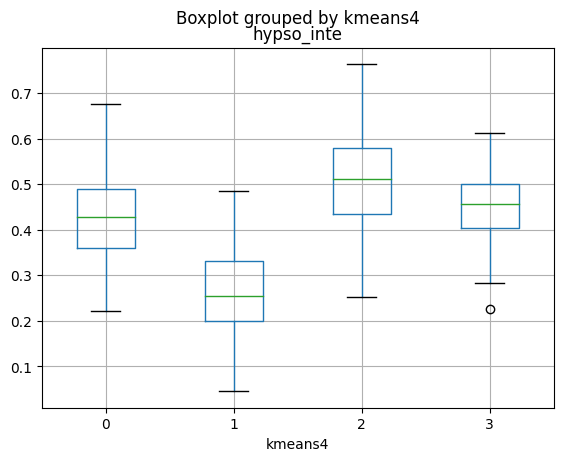

In [114]:
f,ax=plt.subplots()
cat.boxplot(column=['hypso_inte'], by='kmeans4', ax=ax)

<Axes: title={'center': 'slope_mean'}, xlabel='kmeans4'>

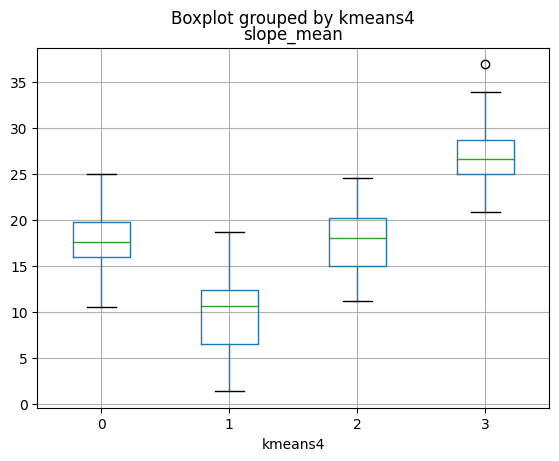

In [115]:
f,ax=plt.subplots()
cat.boxplot(column=['slope_mean'], by='kmeans4', ax=ax)

<Axes: title={'center': 'rel_mean'}, xlabel='kmeans4'>

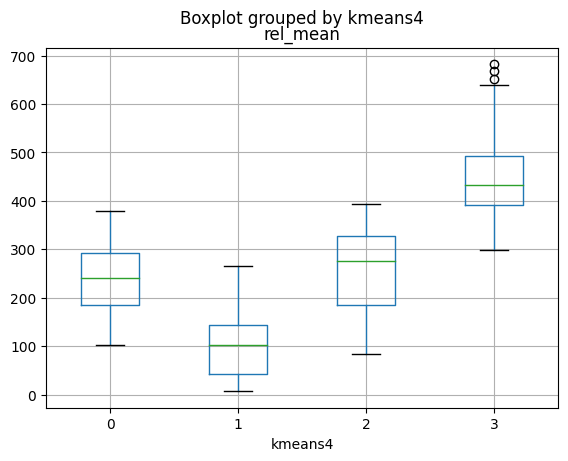

In [116]:
f,ax=plt.subplots()
cat.boxplot(column=['rel_mean'], by='kmeans4', ax=ax)

In [117]:
w_k4 = weights.distance.KNN.from_dataframe(cat, k=4)

In [118]:
cl_k4_wk4 = cluster.AgglomerativeClustering(n_clusters=4, connectivity=w_k4.sparse).fit(cat_std)
print(silhouette_score(cat_std,cl_k4_wk4.labels_))

0.1526421852694735


In [119]:
w_k5 = weights.distance.KNN.from_dataframe(cat, k=5)

In [120]:
cl_k4_wk5 = cluster.AgglomerativeClustering(n_clusters=4, connectivity=w_k5.sparse).fit(cat_std)
print(silhouette_score(cat_std,cl_k4_wk5.labels_))

0.16884430350399734


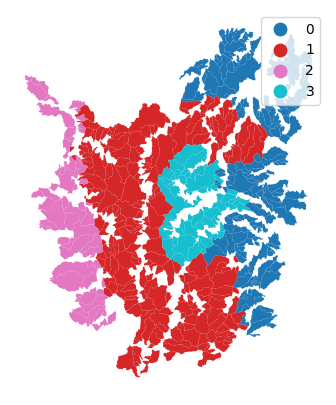

In [121]:
cat['knn5'] = cl_k4_wk5.labels_
f, ax = plt.subplots(1, figsize=(5,5))
cat.plot(column='knn5', categorical=True, legend=True, linewidth=0, ax=ax)
ax.set_axis_off()
plt.savefig('G:\My Drive\INVESTIGACION\POSDOC\Figuras\cluster_k4_wk5.png', dpi=500)

In [122]:
w_k6 = weights.distance.KNN.from_dataframe(cat, k=6)

In [123]:
cl_k4_wk6 = cluster.AgglomerativeClustering(n_clusters=4, connectivity=w_k6.sparse).fit(cat_std)
print(silhouette_score(cat_std,cl_k4_wk6.labels_))

0.12040468188608276


In [124]:
w_kernel4 = weights.distance.Kernel.from_dataframe(cat,fixed=False,function='gaussian',k=4)

In [125]:
cl_kernel4 = cluster.AgglomerativeClustering(n_clusters=4, connectivity=w_kernel4.sparse).fit(cat_std)
print(silhouette_score(cat_std,cl_kernel4.labels_))

0.1526421852694735


In [126]:
w_d30 = weights.DistanceBand.from_dataframe(cat, 30000, binary=False)

C:\Users\edier\miniconda3\Lib\site-packages\scipy\sparse\_data.py:119: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)


In [127]:
cl_d30 = cluster.AgglomerativeClustering(n_clusters=4, connectivity=w_d30.sparse).fit(cat_std)
print(silhouette_score(cat_std,cl_d30.labels_))

0.1568205278949805


In [128]:
cat.head(1)

,id,Nombre,ID_CUENCA,cuenca,area,elev_mean,elev_median,rel_mean,rel_median,rainfallAnnual_mean,...,slope_mean,kmeans,RainfallDaysmean,RainfallDaysmedian,landcovermedian,geomedian,lands_rec,geometry,kmeans4,knn5
0,1,Quebrada Guaco,606.0,Cauca,18443928,1615.334363,1607.0,510.665139,505.0,2264.807895,...,29.278027,C,1112.245024,1066.0,grass,sediment,4.0,"POLYGON ((454732.740 622820.251, 454684.825 62...",3,1


In [129]:
cat["knn5"]=np.where(cat["knn5"]==0,"A",cat["knn5"])
cat["knn5"]=np.where(cat["knn5"]=="1","B",cat["knn5"])
cat["knn5"]=np.where(cat["knn5"]=="2","C",cat["knn5"])
cat["knn5"]=np.where(cat["knn5"]=="3","D",cat["knn5"])
cat.head(1)

,id,Nombre,ID_CUENCA,cuenca,area,elev_mean,elev_median,rel_mean,rel_median,rainfallAnnual_mean,...,slope_mean,kmeans,RainfallDaysmean,RainfallDaysmedian,landcovermedian,geomedian,lands_rec,geometry,kmeans4,knn5
0,1,Quebrada Guaco,606.0,Cauca,18443928,1615.334363,1607.0,510.665139,505.0,2264.807895,...,29.278027,C,1112.245024,1066.0,grass,sediment,4.0,"POLYGON ((454732.740 622820.251, 454684.825 62...",3,B


In [130]:
cat["kmeans4"]=np.where(cat["kmeans4"]==0,"A",cat["kmeans4"])
cat["kmeans4"]=np.where(cat["kmeans4"]=="1","B",cat["kmeans4"])
cat["kmeans4"]=np.where(cat["kmeans4"]=="2","C",cat["kmeans4"])
cat["kmeans4"]=np.where(cat["kmeans4"]=="3","D",cat["kmeans4"])
cat.head(1)

,id,Nombre,ID_CUENCA,cuenca,area,elev_mean,elev_median,rel_mean,rel_median,rainfallAnnual_mean,...,slope_mean,kmeans,RainfallDaysmean,RainfallDaysmedian,landcovermedian,geomedian,lands_rec,geometry,kmeans4,knn5
0,1,Quebrada Guaco,606.0,Cauca,18443928,1615.334363,1607.0,510.665139,505.0,2264.807895,...,29.278027,C,1112.245024,1066.0,grass,sediment,4.0,"POLYGON ((454732.740 622820.251, 454684.825 62...",D,B


In [131]:
cat.to_file("G:\My Drive\INVESTIGACION\POSDOC\Data\Vector\df_catchments_kmeans.gpkg", driver="GPKG")